# 16.6.1 有限决策过程与策略评价

## 学习目标与先修知识

给定转移和策略，解 Bellman 线性方程并独立迭代核验。

先修：5.4 马尔可夫（Markov）过程；10.5 Bellman 递推；线性方程组（system of linear equations）。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

调节单元在有限状态（state）中选择动作；固定策略未来能获得多少折扣回报？终止状态还会产生后续奖励吗？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
gamma=.9;p=.8;print("状态0选择动作0时解析价值：",1/(1-gamma*p))

状态0选择动作0时解析价值： 3.5714285714285725


## 模型假设

两个状态、两个动作；状态1 为终止吸收态（absorbing state），后续奖励为0。每个转移行是概率分布（probability distribution），$0\le\gamma<1$。价值单位与即时奖励一致，策略每状态指定一个动作。

## 数学解释与推导

固定策略 $\pi$ 的 Bellman 方程是 $V^\pi=r_\pi+\gamma P_\pi V^\pi$，因此 $(I-\gamma P_\pi)V^\pi=r_\pi$。终止态用零奖励、自循环的吸收行表示，其价值为0；不能在终止后再累计非零奖励。这里用已知模型求策略价值，下一节转向利用经验记录更新动作价值。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def policy_values(transitions,rewards,policy,gamma):
    P=np.asarray(transitions,dtype=float);R=np.asarray(rewards,dtype=float)
    pi=np.asarray(policy,dtype=int);indices=np.arange(len(pi))
    chosen=P[indices,pi,:];reward=R[indices,pi]
    return np.linalg.solve(np.eye(len(pi))-gamma*chosen,reward).tolist()

## 对照实验

固定策略与转移表，从零价值开始反复进行 Bellman 更新，比较迭代值与线性方程解的距离。

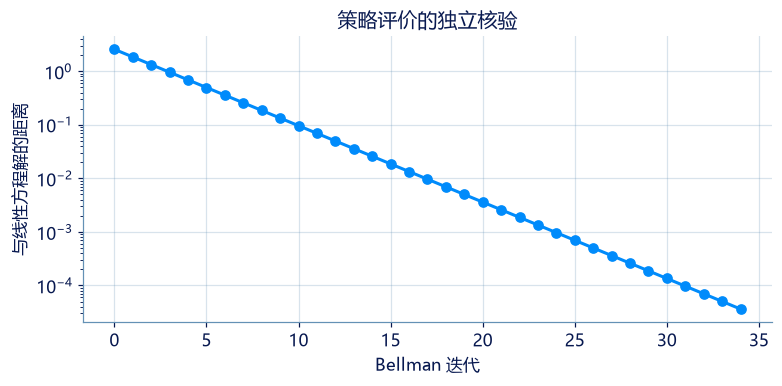

策略价值： [3.57142857 0.        ]


In [4]:
P=[[[.8,.2],[.2,.8]],[[0.,1.],[0.,1.]]];R=[[1.,0.],[0.,0.]];policy=[0,0];exact=np.asarray(policy_values(P,R,policy,.9));value=np.zeros(2);errors=[]
for _ in range(35):value=np.array([1.,0.])+.9*np.array([[.8,.2],[0.,1.]])@value;errors.append(np.linalg.norm(value-exact))
fig,ax=plt.subplots(figsize=(7,3.4));ax.semilogy(errors,"o-",color=BLUE);ax.set(xlabel="Bellman 迭代",ylabel="与线性方程解的距离",title="策略评价的独立核验");ax.grid(alpha=.25);plt.show()
print("策略价值：",exact)

## 结果解释

线性方程解与反复 Bellman 更新逐步一致；这只针对已知小模型和固定策略。改变转移概率（probability）或评估任务，应重新计算。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
np.testing.assert_allclose(exact[0],1/(1-.9*.8));np.testing.assert_allclose(exact[1],0.)
assert errors[-1]<errors[0]
print("解析几何级数、终止态和迭代核验通过。")

解析几何级数、终止态和迭代核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-06-%E5%BC%BA%E5%8C%96%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%AD%96%E7%95%A5%E8%AF%84%E4%BC%B0/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：终止后价值

终止吸收态（absorbing state）每步奖励0，固定策略下其价值为多少？

- **A.** 0。
- **B.** 1/(1-γ)。
- **C.** 等于状态（state）编号。
- **D.** 无法定义。

[作答：终止后价值](http://127.0.0.1:8000/chapters/16-06-%E5%BC%BA%E5%8C%96%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%AD%96%E7%95%A5%E8%AF%84%E4%BC%B0/practice/?question=p16-terminal-reward)

### 第 2 题 · 单项选择题：策略评价的对象

已知转移表下求 Vπ，主要得到什么？

- **A.** 新环境下学习策略的独立效果。
- **B.** 固定策略在给定 MDP 中的期望（expectation）折扣回报。
- **C.** 真实生理控制器的因果效果。
- **D.** 每条随机轨迹（trajectory）完全相同的回报。

[作答：策略评价的对象](http://127.0.0.1:8000/chapters/16-06-%E5%BC%BA%E5%8C%96%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%AD%96%E7%95%A5%E8%AF%84%E4%BC%B0/practice/?question=p16-policy-vs-learning)

### 第 3 题 · Python 计算题：固定策略的折扣价值

按 Vπ=rπ+γPπVπ 解线性方程，返回各状态（state）价值。

**函数与代码模板**

```python
def solve(
    transitions: list,
    rewards: list,
    policy: list[int],
    gamma: float,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `transitions` | `list` | 数组（array）形状为状态×动作×后继状态，各行概率（probability）和为1。 | 1 |
| `rewards` | `list` | 状态×动作的即时奖励。 | 奖励 |
| `policy` | `list[int]` | 每状态选定的动作编号。 | 1 |
| `gamma` | `float` | 折扣因子。 | 1 |

**返回值**

直接返回 values（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 固定策略下每状态的期望（expectation）折扣回报。 | 奖励 |

**计算规则**

按固定 policy 抽取 P_pi 与 r_pi，求解 (I-gamma*P_pi)V=r_pi。

**约束与边界**

- 2—8 个状态，每状态1—4个动作；转移非负且每行和为1；policy 动作合法，0≤gamma<1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| transitions | 数组（array）形状为状态×动作×后继状态，各行概率（probability）和为1。 | [[[0.0, 1.0]], [[0.0, 1.0]]] | 1 |
| rewards | 状态×动作的即时奖励。 | [[1.0], [0.0]] | 奖励 |
| policy | 每状态选定的动作编号。 | [0, 0] | 1 |
| gamma | 折扣因子。 | 0.5 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
transitions = [[[0.0, 1.0]], [[0.0, 1.0]]]
rewards = [[1.0], [0.0]]
policy = [0, 0]
gamma = 0.5

result = solve(transitions, rewards, policy, gamma)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| values | 固定策略下每状态的期望（expectation）折扣回报。 | [1.0, 0.0] | 奖励 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0, 0.0]
```

**样例解释**

首例状态1为零奖励终止吸收态（absorbing state），价值0；状态0本步奖励1，因此价值1。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：固定策略的折扣价值](http://127.0.0.1:8000/chapters/16-06-%E5%BC%BA%E5%8C%96%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%AD%96%E7%95%A5%E8%AF%84%E4%BC%B0/practice/?question=p16-policy-bellman)

### 第 4 题 · Python 计算题：两状态策略评价

给定策略而非学习策略，返回明确模型（model）下的 Bellman 价值。

**函数与代码模板**

```python
def solve(
    transitions: list,
    rewards: list,
    policy: list[int],
    gamma: float,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `transitions` | `list` | 状态（state）×动作×后继状态转移概率（probability）。 | 1 |
| `rewards` | `list` | 状态×动作的即时奖励。 | 奖励 |
| `policy` | `list[int]` | 各状态固定动作编号。 | 1 |
| `gamma` | `float` | 折扣率。 | 1 |

**返回值**

直接返回 values（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 每个状态的价值。 | 奖励 |

**计算规则**

按固定 policy 抽取 P_pi 与 r_pi，求解 (I-gamma*P_pi)V=r_pi。

**约束与边界**

- 2—8 个状态，每状态1—4个动作；转移非负且每行和为1；policy 动作合法，0≤gamma<1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| transitions | 状态（state）×动作×后继状态转移概率（probability）。 | [[[1.0, 0.0]], [[0.0, 1.0]]] | 1 |
| rewards | 状态×动作的即时奖励。 | [[1.0], [0.0]] | 奖励 |
| policy | 各状态固定动作编号。 | [0, 0] | 1 |
| gamma | 折扣率。 | 0.5 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
transitions = [[[1.0, 0.0]], [[0.0, 1.0]]]
rewards = [[1.0], [0.0]]
policy = [0, 0]
gamma = 0.5

result = solve(transitions, rewards, policy, gamma)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| values | 每个状态的价值。 | [2.0, 0.0] | 奖励 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [2.0, 0.0]
```

**样例解释**

首例状态0每步都得1，折扣和为1/(1-0.5)=2；状态1价值0。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：两状态策略评价](http://127.0.0.1:8000/chapters/16-06-%E5%BC%BA%E5%8C%96%E5%AD%A6%E4%B9%A0%E4%B8%8E%E7%AD%96%E7%95%A5%E8%AF%84%E4%BC%B0/practice/?question=p16-policy-compare)

**进一步阅读**

[Watkins 与 Dayan 的 Q-learning 原论文](https://www.gatsby.ucl.ac.uk/~dayan/papers/cjch.pdf)将值更新与动态规划联系；本节先做已知模型的策略评价。